In [1]:
import torch
import torch.nn as nn 
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [2]:
# device config 
device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# defining the hyperparameters.
EPOCHS = 30
BATCH_SIZE = 100
LEARNING_RATE = 0.001

# defining the Image preprocessing stuffs 
im_transform = transforms.Compose([
    transforms.Pad(4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32),
    transforms.ToTensor()
])

# downloading the CIFAR-10 dataset. 
train_dataset = datasets.CIFAR10('./data', train=True, transform=im_transform, download=True)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transforms.ToTensor())

# loading the datasets. 
test_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ResNet Model. 

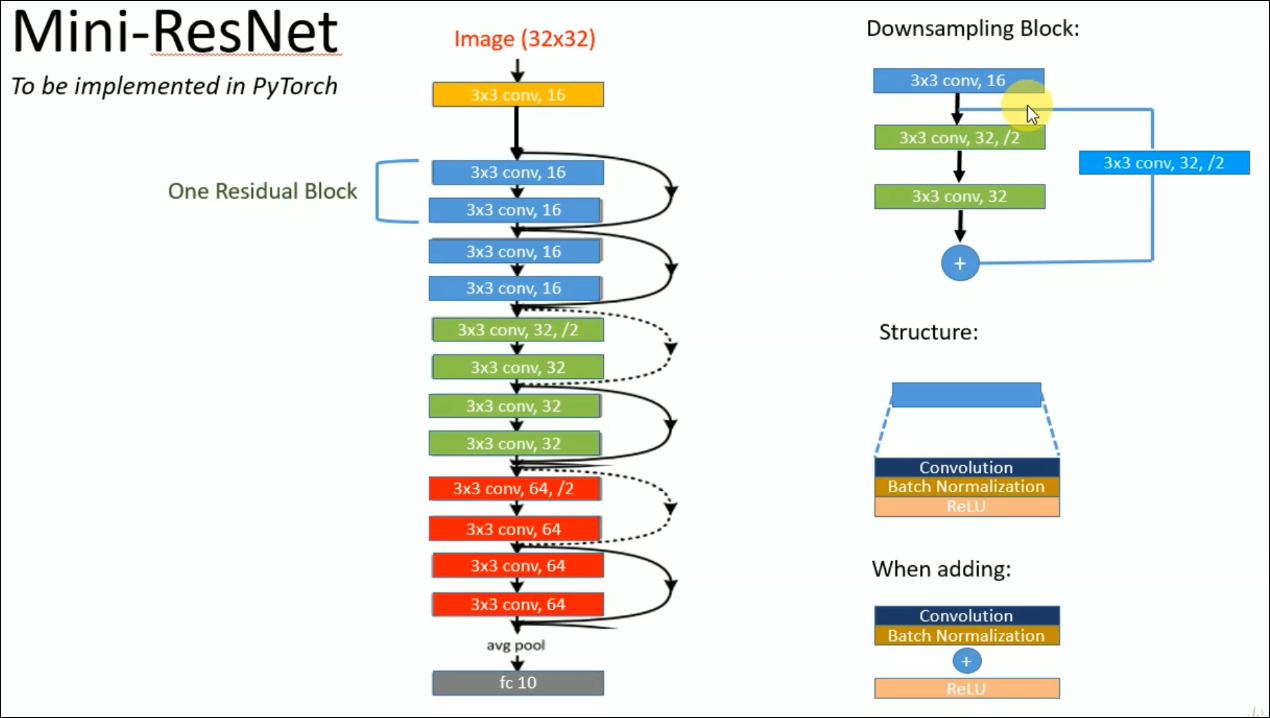

In [3]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, down_sampling=None) -> None:
        super(ResidualBlock, self).__init__()
        
        # first convolution block 
        self.conv1 = conv3x3(in_channels=in_channels, out_channels=out_channels, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # second convolution block
        self.conv2 = conv3x3(in_channels=out_channels, out_channels=out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.down_sampling = down_sampling

    def forward(self, x):
        residual = x.clone()
        out = self.conv1(x)
        out = self.bn1(x)
        out = self.relu(x)

        out = self.conv2(x)
        out = self.bn2(x)
        
        if self.down_sampling:
            residual = self.down_sampling(x) 

        out += residual
        out = self.relu(out)
        
        return out


In [7]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10) -> None:
        """
        layers will be a list: [2, 2, 2]
        """
        super().__init__()

        self.in_channels = 16

        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0], stride=1)
        self.layer2 = self.make_layer(block, 32, layers[1], stride=2)
        self.layer3 = self.make_layer(block, 64, layers[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(8)
        self.fc = nn.Linear(64, num_classes)


    def make_layer(self, block, out_channels, n_block, stride=1):
        down_sampling = None

        if (self.in_channels != out_channels) or (stride != 1):
            down_sampling = nn.Sequential(conv3x3(self.in_channels, out_channels, stride=stride), nn.BatchNorm2d(out_channels))

        residual_blocks = []

        residual_blocks.append(block(self.in_channels, out_channels, stride=stride, down_sampling=down_sampling))
        self.in_channels = out_channels

        residual_blocks.append(block(self.in_channels, out_channels))

        return nn.Sequential(*residual_blocks)
    
    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avgpool(out)
        out = out.view(out, 1)
        out = self.fc(out)

        return out


In [8]:
model = ResNet(ResidualBlock, [2, 2, 2])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [9]:
decay = 0
model.train()
for epoch in range(EPOCHS):

    # decay the learning rate every 20 epochs. 
    if (epoch + 1)%20 == 0:
        decay+=1
        optimizer.param_groups[0]['lr'] *= 0.5**decay

        print(f"The new learning rate is: {optimizer.param_groups[0]['lr']}")

    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1)%100 == 0:
            print(f"Epoch {epoch}/{EPOCHS}, Loss: {loss.item()}")

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
# testing mode

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100*correct/total} ")